In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('.'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

./creditcard.csv
./.config/.last_update_check.json
./.config/.last_opt_in_prompt.yaml
./.config/default_configs.db
./.config/active_config
./.config/gce
./.config/.last_survey_prompt.yaml
./.config/config_sentinel
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
./.config/logs/2025.12.09/14.41.33.792924.log
./.config/logs/2025.12.09/14.41.43.412452.log
./.config/logs/2025.12.09/14.41.42.675750.log
./.config/logs/2025.12.09/14.41.27.893750.log
./.config/logs/2025.12.09/14.41.18.717681.log
./.config/logs/2025.12.09/14.40.47.605300.log
./.config/configurations/config_default
./sample_data/README.md
./sample_data/anscombe.json
./sample_data/california_housing_train.csv
./sample_data/mnist_test.csv
./sample_data/california_housing_test.csv
./sample_data/mnist_train_small.csv


In [2]:
!pip install -U pip
!git clone https://github.com/riri324/CTGAN.git
%cd CTGAN
!pip install -e .

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 46.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Cloning into 'CTGAN'...
remote: Enumerating objects: 2357, done.
remote: Counting objects: 100% (1009/1009), done.
remote: Compressing objects: 100% (258/258), done.
remote: Total 2357 (delta 924), reused 751 (delta 751), pack-reused 1348 (from 3)
Receiving objects: 100% (2357/2357), 1.97 MiB | 14.80 MiB/s, done.
Resolving deltas: 100% (1471/1471), done.
/content/CTGAN
Obtaining file:///content/CTGAN
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 17.0 MB/s  0:00:00
  Building editable for ctgan (pyproject.toml) ... done
  Created wheel for ctgan: filename=ct

In [3]:
import pkgutil, sys
print("python:", sys.executable)
print("ctgan exists?", any(m.name == "ctgan" for m in pkgutil.iter_modules()))


python: /usr/bin/python3
ctgan exists? True


In [4]:
import os
import pandas as pd

data_path = "/content/creditcard.csv"

df = pd.read_csv(data_path)

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# from sklearn.model_selection import train_test_split

# # use 5% of dataset
# df_small, _ = train_test_split(
#     df,
#     test_size=0.95,              
#     stratify=df["Class"],      
#     random_state=42
# )

# print("Small DF shape:", df_small.shape)
# print("Fraud ratio:", df_small["Class"].mean())

In [ ]:
import numpy as np
import pandas as pd
import time

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, recall_score

from xgboost import XGBClassifier
from ctgan import CTGAN

# Hold-out split: Baseline / GAN / Diffusion for same standards for test
train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df["Class"], random_state=42
)
train_base, val_df = train_test_split(
    train_df, test_size=0.2, stratify=train_df["Class"], random_state=42
)
FEATURE_COLS = [c for c in df.columns if c != "Class"]

# train_df, test_df = train_test_split(
#     df_small, test_size=0.2, stratify=df_small["Class"], random_state=42
# )

# train_base, val_df = train_test_split(
#     train_df, test_size=0.2, stratify=train_df["Class"], random_state=42
# )

# FEATURE_COLS = [c for c in df_small.columns if c != "Class"]

print("Train fraud rate:", train_df["Class"].mean())
print("Test  fraud rate:", test_df["Class"].mean())

ratios = [0.3, 0.5, 0.7, 1.0]
ratios_ext = [None] + ratios          # natural (None)
discrete_columns = ["Class"]

def ratio_name(r):
    return "natural" if r is None else f"forced_{r:.2f}"

scale_pos_weight = (train_df["Class"].value_counts()[0] / train_df["Class"].value_counts()[1])
print("scale_pos_weight:", scale_pos_weight)

Train fraud rate: 0.001729245759178389
Test  fraud rate: 0.0017204452090867595
scale_pos_weight: 577.2868020304569


In [7]:
def find_best_threshold(prob, y_true):
    thresholds = np.linspace(0.001, 0.5, 200)
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        pred = (prob > t).astype(int)
        f1 = f1_score(y_true, pred)
        if f1 > best_f1:
            best_f1, best_t = float(f1), float(t)
    return best_t, best_f1

In [8]:
from sklearn.metrics import pairwise_distances

def privacy_nn_memorization(real_df, syn_df, feature_cols, threshold=1e-6,
                            sample_real=5000, sample_syn=5000, seed=42):
    real_s = real_df.sample(n=min(sample_real, len(real_df)), random_state=seed)
    syn_s  = syn_df.sample(n=min(sample_syn, len(syn_df)), random_state=seed)

    real_X = real_s[feature_cols].values
    syn_X  = syn_s[feature_cols].values

    dists = pairwise_distances(syn_X, real_X, metric="euclidean")
    min_dists = dists.min(axis=1)

    out = {
        "NN_mean": float(min_dists.mean()),
        "NN_min": float(min_dists.min()),
        "NearDup_rate(thr)": float((min_dists < threshold).mean())
    }

    real_fraud = real_df[real_df.Class==1]
    syn_fraud  = syn_df[syn_df.Class==1]
    if len(real_fraud) > 0 and len(syn_fraud) > 0:
        rf = real_fraud.sample(n=min(2000, len(real_fraud)), random_state=seed)[feature_cols].values
        sf = syn_fraud.sample(n=min(2000, len(syn_fraud)), random_state=seed)[feature_cols].values
        d_f = pairwise_distances(sf, rf, metric="euclidean")
        min_d_f = d_f.min(axis=1)
        out["Fraud_NN_mean"] = float(min_d_f.mean())
        out["Fraud_NN_min"]  = float(min_d_f.min())
    else:
        out["Fraud_NN_mean"] = np.nan
        out["Fraud_NN_min"]  = np.nan

    return out

def real_real_nn_baseline(real_df, feature_cols, class_value=None, n_sample=2000, seed=42):
    if class_value is None:
        X = real_df[feature_cols].values
    else:
        X = real_df[real_df["Class"] == class_value][feature_cols].values

    rng = np.random.default_rng(seed)
    n = min(n_sample, len(X))
    if n < 2:
        return {"RealReal_NN_mean": np.nan, "RealReal_NN_min": np.nan, "n_used": n}

    idx1 = rng.choice(len(X), n, replace=False)
    idx2 = rng.choice(len(X), n, replace=False)
    X1, X2 = X[idx1], X[idx2]

    d = pairwise_distances(X1, X2, metric="euclidean")
    np.fill_diagonal(d, np.inf)
    min_d = d.min(axis=1)
    return {"RealReal_NN_mean": float(min_d.mean()), "RealReal_NN_min": float(min_d.min()), "n_used": n}


In [ ]:
privacy_rows_ctgan = []
imbalance_rows_ctgan = []

# Real-Real baseline
baseline_all  = real_real_nn_baseline(train_base, FEATURE_COLS, class_value=None, n_sample=2000)
baseline_fraud = real_real_nn_baseline(train_base, FEATURE_COLS, class_value=1, n_sample=2000)

baseline_df = pd.DataFrame([
    {"syn_ratio": "BASELINE_REALREAL_ALL",
     "NN_mean": baseline_all["RealReal_NN_mean"],
     "NN_min":  baseline_all["RealReal_NN_min"]},
    {"syn_ratio": "BASELINE_REALREAL_FRAUD",
     "Fraud_NN_mean": baseline_fraud["RealReal_NN_mean"],
     "Fraud_NN_min":  baseline_fraud["RealReal_NN_min"]},
]).set_index("syn_ratio")


In [ ]:
def evaluate_holdout_xgb(train_any_df, val_df, test_df, xgb_params):
    X_train = train_any_df.drop(columns=["Class"])
    y_train = train_any_df["Class"]

    X_val = val_df.drop(columns=["Class"])
    y_val = val_df["Class"]

    X_test = test_df.drop(columns=["Class"])
    y_test = test_df["Class"]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s   = scaler.transform(X_val)
    X_test_s  = scaler.transform(X_test)

    model = XGBClassifier(**xgb_params)
    model.fit(X_train_s, y_train)

    val_prob = model.predict_proba(X_val_s)[:, 1]
    best_t, best_f1 = find_best_threshold(val_prob, y_val)

    test_prob = model.predict_proba(X_test_s)[:, 1]
    pred_fixed = (test_prob > 0.5).astype(int)
    pred_opt   = (test_prob > best_t).astype(int)

    return {
        "ROC-AUC": roc_auc_score(y_test, test_prob),
        "AUPRC": average_precision_score(y_test, test_prob),
        "F1@0.5": f1_score(y_test, pred_fixed),
        "Recall@0.5": recall_score(y_test, pred_fixed),
        "F1@opt": f1_score(y_test, pred_opt),
        "Recall@opt": recall_score(y_test, pred_opt),
        "Best_threshold": best_t,
        "Best_F1_on_VAL": best_f1
    }

In [ ]:
# Hold-out Baseline / GAN / Diffusion same parameters for fairness
XGB_PARAMS = dict(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)
XGB_PARAMS_ON  = {**XGB_PARAMS, "scale_pos_weight": scale_pos_weight}
XGB_PARAMS_OFF = {**XGB_PARAMS}

# baseline_holdout = evaluate_holdout_xgb(train_df, test_df, XGB_PARAMS)
# baseline_holdout

In [ ]:
def make_hybrid(real_df, syn_df):
    return pd.concat([real_df, syn_df], axis=0).sample(
        frac=1, random_state=42
    ).reset_index(drop=True)

ctgan_models = {}
ctgan_syn = {}              # for each ratio save syn (for quality/ tsne)
ctgan_results = {}

for r in ratios_ext:
    name = ratio_name(r)
    print(f"\n[CTGAN] Training ratio = {name}")

    ctgan = CTGAN(
        epochs=300,
        # epochs=200,
        batch_size=500,
        verbose=False,
        ratio=r   # None, natural
    )
    ctgan.set_random_state(42)

    ctgan.fit(train_base, discrete_columns)

    syn = ctgan.sample(len(train_base))

    ctgan_models[name] = ctgan
    ctgan_syn[name] = syn

    # Privacy check: natural + 0.5
    if (r is None) or (abs(r - 0.5) < 1e-12):
        print(f"  -> Running privacy check for {name}")
        priv = privacy_nn_memorization(
            real_df=train_base,
            syn_df=syn,
            feature_cols=FEATURE_COLS,
            threshold=1e-6,
            sample_real=5000,
            sample_syn=5000,
            seed=42
        )
        privacy_rows_ctgan.append({"syn_ratio": name, **priv})

    # (A) SYNTHETIC-ONLY: Train=syn, Test=real
    uniq = np.unique(syn["Class"].values)
    if len(uniq) >= 2:
        ctgan_results[(name, "syn_only_spw_ON")] = evaluate_holdout_xgb(
            syn, val_df, test_df, XGB_PARAMS_ON
        )
        ctgan_results[(name, "syn_only_spw_OFF")] = evaluate_holdout_xgb(
            syn, val_df, test_df, XGB_PARAMS_OFF
        )
    else:
        print(f"  -> skip syn-only (only one class in syn): {uniq}")

    # (B) HYBRID: Train=real+syn, Test=real
    hybrid_train = make_hybrid(train_base, syn)

    imbalance_rows_ctgan.append({
        "syn_ratio_setting": name,
        "hybrid_fraud_ratio": float(hybrid_train["Class"].mean())
    })

    ctgan_results[(name, "hybrid_spw_ON")] = evaluate_holdout_xgb(
        hybrid_train, val_df, test_df, XGB_PARAMS_ON
    )
    ctgan_results[(name, "hybrid_spw_OFF")] = evaluate_holdout_xgb(
        hybrid_train, val_df, test_df, XGB_PARAMS_OFF
    )

# save table
ctgan_df = pd.DataFrame(ctgan_results).T
ctgan_df.index = pd.MultiIndex.from_tuples(ctgan_df.index, names=["syn_ratio", "train_setting"])
ctgan_df = ctgan_df.sort_index()
ctgan_df.to_csv("ctgan_results_syn_only_and_hybrid.csv")
display(ctgan_df)

privacy_ctgan_df = pd.DataFrame(privacy_rows_ctgan).set_index("syn_ratio")
privacy_ctgan_df.to_csv("ctgan_privacy_nn_memorization_natural_and_05.csv")
display(privacy_ctgan_df)
display(baseline_df)



[CTGAN] Training ratio = natural


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  -> Running privacy check for natural

[CTGAN] Training ratio = forced_0.30

[CTGAN] Training ratio = forced_0.50
  -> Running privacy check for forced_0.50

[CTGAN] Training ratio = forced_0.70

[CTGAN] Training ratio = forced_1.00
  -> skip syn-only (only one class in syn): [1]


ROC-AUC     AUPRC    F1@0.5  Recall@0.5  \
syn_ratio   train_setting                                                
forced_0.30 hybrid_spw_OFF    0.973918  0.833173  0.712446    0.846939   
            hybrid_spw_ON     0.979721  0.793875  0.088265    0.897959   
            syn_only_spw_OFF  0.976124  0.668286  0.114029    0.908163   
            syn_only_spw_ON   0.976178  0.686910  0.022164    0.948980   
forced_0.50 hybrid_spw_OFF    0.979908  0.851509  0.770642    0.857143   
            hybrid_spw_ON     0.983069  0.837250  0.157522    0.908163   
            syn_only_spw_OFF  0.980360  0.681138  0.231183    0.877551   
            syn_only_spw_ON   0.979253  0.674269  0.050819    0.918367   
forced_0.70 hybrid_spw_OFF    0.978206  0.853657  0.798077    0.846939   
            hybrid_spw_ON     0.980373  0.827490  0.034949    0.948980   
            syn_only_spw_OFF  0.979101  0.647926  0.304729    0.887755   
            syn_only_spw_ON   0.973367  0.696939  0.004744    0.989796   
forced_1.00 hybrid_spw_OFF    0.983782  0.818732  0.646154    0.857143   
            hybrid_spw_ON     0.987746  0.782629  0.047155    0.938776   
natural     hybrid_spw_OFF    0.980361  0.833572  0.746667    0.857143   
            hybrid_spw_ON     0.981647  0.812901  0.143541    0.918367   
            syn_only_spw_OFF  0.974094  0.728216  0.144398    0.887755   
            syn_only_spw_ON   0.979294  0.702669  0.038095    0.918367   

                                F1@opt  Recall@opt  Best_threshold  \
syn_ratio   train_setting                                            
forced_0.30 hybrid_spw_OFF    0.712446    0.846939        0.500000   
            hybrid_spw_ON     0.088265    0.897959        0.500000   
            syn_only_spw_OFF  0.114029    0.908163        0.500000   
            syn_only_spw_ON   0.022164    0.948980        0.500000   
forced_0.50 hybrid_spw_OFF    0.770642    0.857143        0.500000   
            hybrid_spw_ON     0.157522    0.908163        0.500000   
            syn_only_spw_OFF  0.231183    0.877551        0.500000   
            syn_only_spw_ON   0.050819    0.918367        0.500000   
forced_0.70 hybrid_spw_OFF    0.794258    0.846939        0.492477   
            hybrid_spw_ON     0.034949    0.948980        0.500000   
            syn_only_spw_OFF  0.304729    0.887755        0.500000   
            syn_only_spw_ON   0.004744    0.989796        0.500000   
forced_1.00 hybrid_spw_OFF    0.646154    0.857143        0.500000   
            hybrid_spw_ON     0.047155    0.938776        0.500000   
natural     hybrid_spw_OFF    0.746667    0.857143        0.500000   
            hybrid_spw_ON     0.143541    0.918367        0.500000   
            syn_only_spw_OFF  0.144398    0.887755        0.500000   
            syn_only_spw_ON   0.038095    0.918367        0.500000   

                              Best_F1_on_VAL  
syn_ratio   train_setting                     
forced_0.30 hybrid_spw_OFF          0.719101  
            hybrid_spw_ON           0.085928  
            syn_only_spw_OFF        0.110749  
            syn_only_spw_ON         0.022380  
forced_0.50 hybrid_spw_OFF          0.696629  
            hybrid_spw_ON           0.151648  
            syn_only_spw_OFF        0.224490  
            syn_only_spw_ON         0.048017  
forced_0.70 hybrid_spw_OFF          0.738095  
            hybrid_spw_ON           0.034139  
            syn_only_spw_OFF        0.288172  
            syn_only_spw_ON         0.004696  
forced_1.00 hybrid_spw_OFF          0.627451  
            hybrid_spw_ON           0.045022  
natural     hybrid_spw_OFF          0.775758  
            hybrid_spw_ON           0.140530  
            syn_only_spw_OFF        0.142268  
            syn_only_spw_ON         0.036630

,NN_mean,NN_min,NearDup_rate(thr),Fraud_NN_mean,Fraud_NN_min
syn_ratio,,,,,
natural,89.441439,3.667036,0.0,605.456400,10.142715
forced_0.50,82.979059,3.696937,0.0,554.536252,7.650610


,NN_mean,NN_min,Fraud_NN_mean,Fraud_NN_min
syn_ratio,,,,
BASELINE_REALREAL_ALL,94.506707,0.0,NaN,NaN
BASELINE_REALREAL_FRAUD,NaN,NaN,2.434491,0.0


In [13]:
print(ctgan_models["natural"].loss_values.columns)

Index(['Epoch', 'Generator Loss', 'Discriminator Loss'], dtype='object')


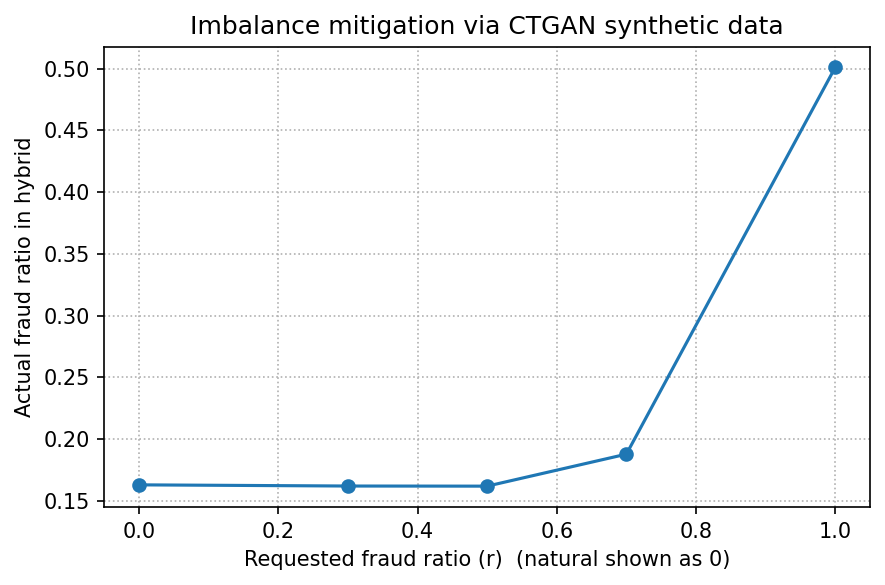

,syn_ratio_setting,hybrid_fraud_ratio,requested_r
0,natural,0.163019,0.0
1,forced_0.30,0.162070,0.3
2,forced_0.50,0.161971,0.5
3,forced_0.70,0.187850,0.7
4,forced_1.00,0.500864,1.0


In [15]:
import matplotlib.pyplot as plt

imbalance_ctgan_df = pd.DataFrame(imbalance_rows_ctgan)

imbalance_ctgan_df["requested_r"] = imbalance_ctgan_df["syn_ratio_setting"].apply(
    lambda s: 0.0 if s == "natural" else float(s.replace("forced_", ""))
)
imbalance_ctgan_df = imbalance_ctgan_df.sort_values("requested_r")

plt.figure(figsize=(6,4), dpi=150)
plt.plot(imbalance_ctgan_df["requested_r"], imbalance_ctgan_df["hybrid_fraud_ratio"], marker="o")
plt.xlabel("Requested fraud ratio (r)  (natural shown as 0)")
plt.ylabel("Actual fraud ratio in hybrid")
plt.title("Imbalance mitigation via CTGAN synthetic data")
plt.grid(True, linestyle="dotted")
plt.tight_layout()
plt.show()

display(imbalance_ctgan_df)


In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import pandas as pd

def tsne_real_vs_syn(
    real_df,
    syn_df,
    label_col="Class",
    sample_per_group=5000,
    perplexity=30,
    random_state=42,
    point_size=10,
    alpha=0.55
):
    real_X = real_df.drop(columns=[label_col]).copy()
    syn_X  = syn_df.drop(columns=[label_col]).copy()

    real_X = real_X.sample(n=min(sample_per_group, len(real_X)), random_state=random_state)
    syn_X  = syn_X.sample(n=min(sample_per_group, len(syn_X)), random_state=random_state)

    X = pd.concat([real_X, syn_X], axis=0).reset_index(drop=True)
    domain = np.array(["Real"] * len(real_X) + ["Synthetic"] * len(syn_X))

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # t-SNE
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=random_state
    )
    Z = tsne.fit_transform(X_scaled)

    # Plot
    plt.style.use("seaborn-v0_8")

    fig, ax = plt.subplots(figsize=(7, 6), dpi=150)

    ax.set_facecolor("#EAEAF2")
    ax.grid(True, color="white", linewidth=1.2)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_visible(False)

    for name in ["Real", "Synthetic"]:
        idx = (domain == name)
        ax.scatter(
            Z[idx, 0], Z[idx, 1],
            s=point_size,
            alpha=alpha,
            edgecolors="none",
            label=name
        )

    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    ax.legend(frameon=True, framealpha=0.9)

    plt.tight_layout()
    plt.show()


t-SNE visualization for natural


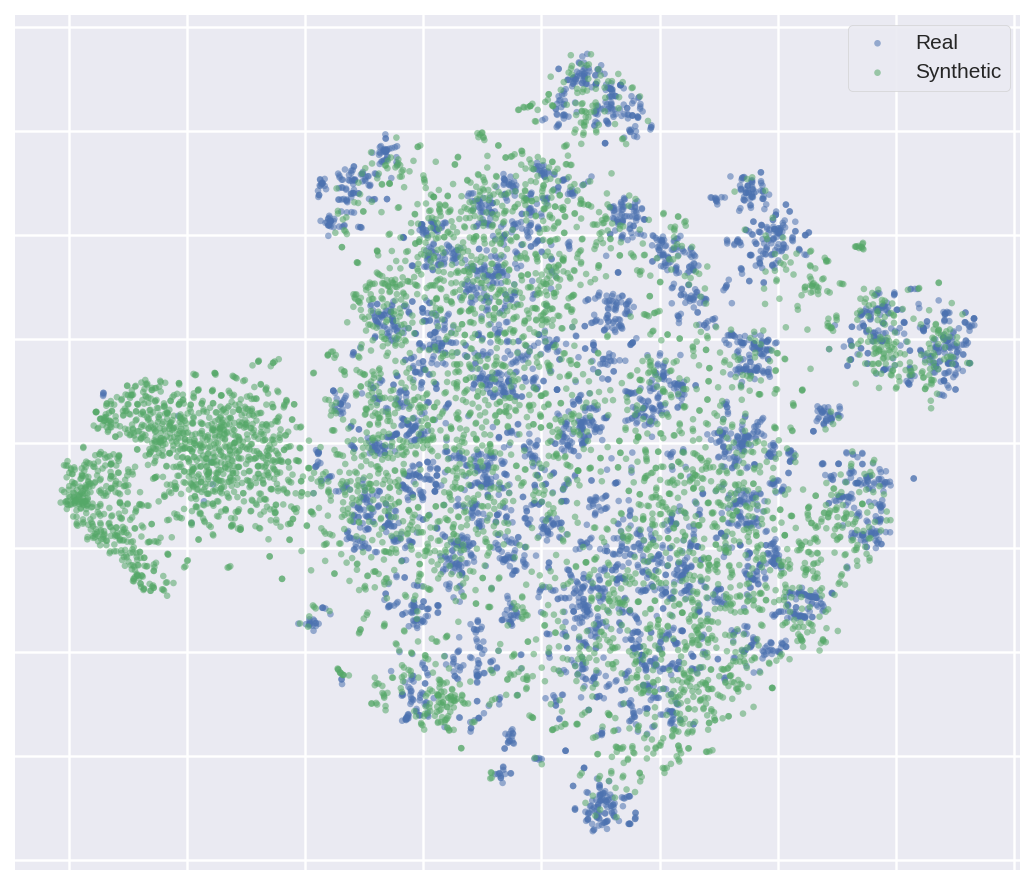

t-SNE visualization for forced_0.50


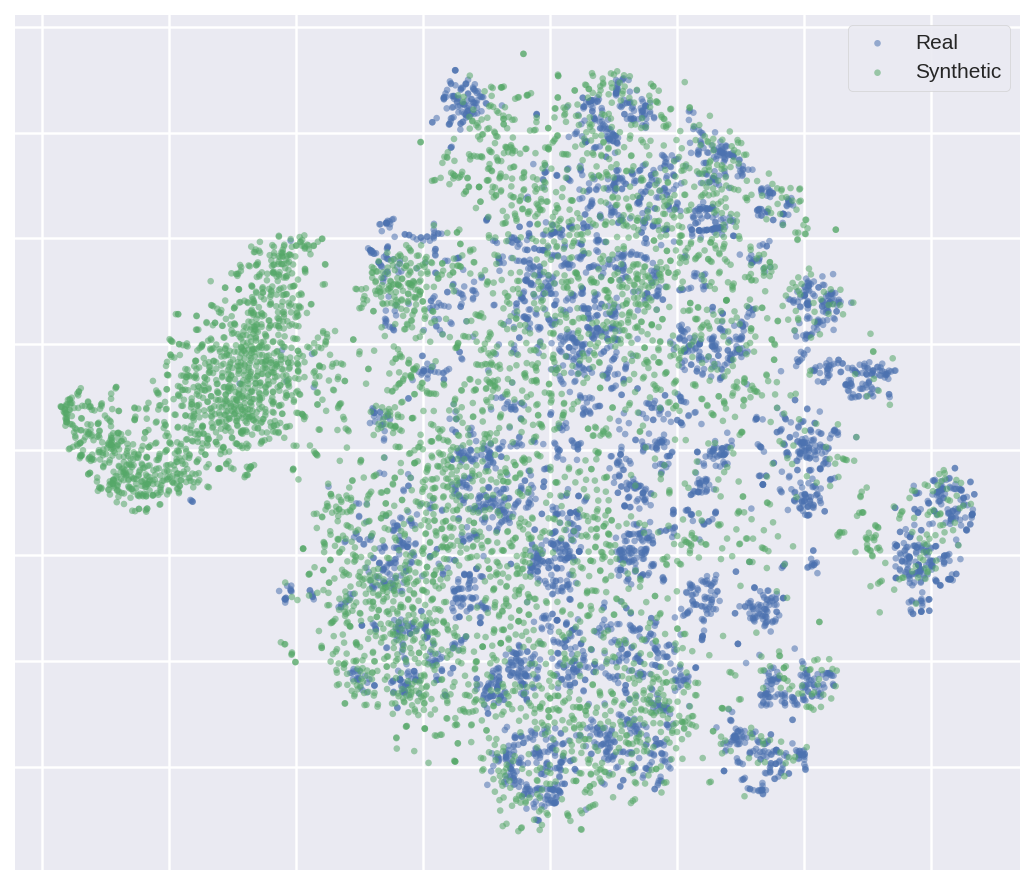

t-SNE FraudOnly visualization for natural


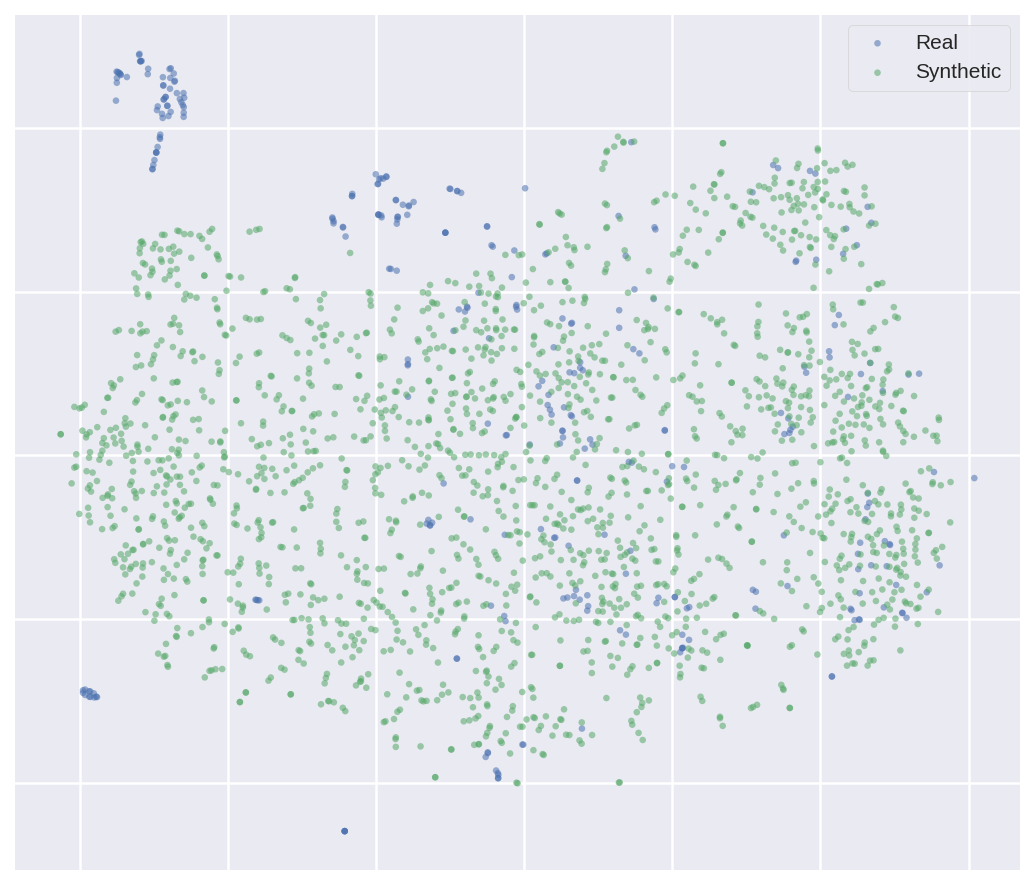

t-SNE FraudOnly visualization for forced_0.50


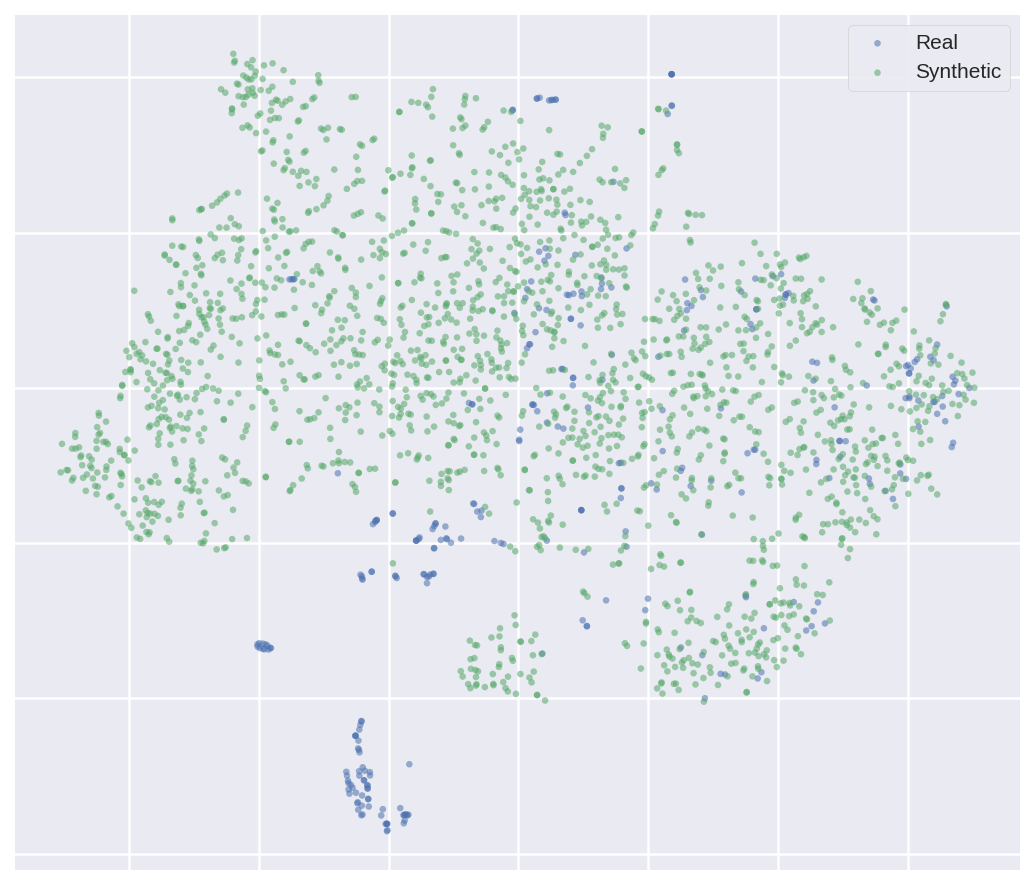

In [17]:
def tsne_fraud_only(real_df, syn_df, label_col="Class", sample=2000):
    real_fraud = real_df[real_df[label_col] == 1]
    syn_fraud  = syn_df[syn_df[label_col] == 1]

    if len(real_fraud) == 0 or len(syn_fraud) == 0:
        print("Fraud samples missing in real or synthetic. Check generation ratio.")
        return

    tsne_real_vs_syn(
        real_fraud,
        syn_fraud,
        label_col=label_col,
        sample_per_group=sample,
        perplexity=20
    )

tsne_targets = ["natural", "forced_0.50"]

for name in tsne_targets:
    print(f"t-SNE visualization for {name}")
    tsne_real_vs_syn(train_base, ctgan_syn[name])

for name in tsne_targets:
    print(f"t-SNE FraudOnly visualization for {name}")
    tsne_fraud_only(train_base, ctgan_syn[name])

In [ ]:
# Synthetic Quality Metrics

from scipy.stats import ks_2samp, wasserstein_distance

def distribution_similarity(real_df, syn_df, exclude_cols=["Class"]):
    ks_scores, wass_scores = [], []
    for col in real_df.columns:
        if col not in exclude_cols:
            ks_scores.append(ks_2samp(real_df[col], syn_df[col]).statistic)
            wass_scores.append(wasserstein_distance(real_df[col], syn_df[col]))
    return {
        "KS_mean": float(np.mean(ks_scores)),
        "Wasserstein_mean": float(np.mean(wass_scores))
    }

def fraud_collapse_check(syn_df, threshold=0.001):
    fr = float(syn_df["Class"].mean())
    return {"Fraud_Ratio": fr, "Collapsed": fr < threshold}

def loss_variance(x):
    return float(np.var(x))

ctgan_quality = {}

for name, syn in ctgan_syn.items():
    real_sample = train_base.sample(
        n=min(len(train_base), len(syn)),
        replace=False,
        random_state=42
    )
    syn_sample = syn.sample(n=len(real_sample), random_state=42)

    lv = ctgan_models[name].loss_values
    gen_var = loss_variance(lv["Generator Loss"].values) if "Generator Loss" in lv else np.nan
    disc_var = loss_variance(lv["Discriminator Loss"].values) if "Discriminator Loss" in lv else np.nan

    ctgan_quality[name] = {
        **distribution_similarity(real_sample, syn_sample),
        **fraud_collapse_check(syn),
        "Gen_Loss_Var": gen_var,
        "Disc_Loss_Var": disc_var,
    }

ctgan_quality_df = pd.DataFrame(ctgan_quality).T.sort_index()
ctgan_quality_df.to_csv("ctgan_quality_with_natural.csv")
display(ctgan_quality_df)


,KS_mean,Wasserstein_mean,Fraud_Ratio,Collapsed,Gen_Loss_Var,Disc_Loss_Var
forced_0.30,0.132345,112.544324,0.322412,False,0.649398,0.030534
forced_0.50,0.164796,116.110028,0.322215,False,0.372334,0.021859
forced_0.70,0.227402,300.673867,0.373971,False,0.049004,0.025378
forced_1.00,0.377793,434.04391,1.0,False,0.043685,0.023736
natural,0.134451,177.801229,0.32431,False,0.76537,0.022327
